# Sequence Modeling

This notebook evaluates whether a sequence model can extract additional
predictive information from the temporal evolution of market-microstructure
features.

A compact Transformer Encoder is used to process sequences of 500 ms feature
vectors. The model is evaluated for both:

1. future-return regression, and
2. DOWN / STATIONARY / UP classification.

The chronological experimental protocol remains unchanged:

- Training: March 16–18
- Validation: March 19
- Test: March 20

Sequences are constructed separately within each trading day so that no input
window crosses an overnight boundary.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)

print("PyTorch version:", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

PyTorch version: 2.14.0
Device: mps


## 1. Data and Model Inputs

The Transformer uses the same compact microstructure feature set used in the
classical models. This keeps the information set fixed so that differences in
performance are attributable primarily to model architecture rather than to
different features.

Each observation represents one 500 ms market state. A sequence therefore
contains the recent evolution of order-book state, order flow, returns,
volatility, and market activity.

In [2]:
PROCESSED_DIR = Path("../data/processed")

assets = ["TSLA", "AMZN", "BRK.B"]

dates = [
    "2026-03-16",
    "2026-03-17",
    "2026-03-18",
    "2026-03-19",
    "2026-03-20",
]

train_dates = [
    "2026-03-16",
    "2026-03-17",
    "2026-03-18",
]

val_dates = ["2026-03-19"]
test_dates = ["2026-03-20"]


def load_processed_day(asset, date):
    safe_asset = asset.replace(".", "_")

    path = PROCESSED_DIR / f"{safe_asset}_{date}.parquet"

    return pd.read_parquet(path)


daily_data = {}

for asset in assets:
    for date in dates:
        daily_data[(asset, date)] = load_processed_day(asset, date)

        print(
            asset,
            date,
            daily_data[(asset, date)].shape
        )

TSLA 2026-03-16 (46800, 75)
TSLA 2026-03-17 (46800, 75)
TSLA 2026-03-18 (46800, 75)
TSLA 2026-03-19 (46800, 75)
TSLA 2026-03-20 (46800, 75)
AMZN 2026-03-16 (46800, 75)
AMZN 2026-03-17 (46800, 75)
AMZN 2026-03-18 (46800, 75)
AMZN 2026-03-19 (46800, 75)
AMZN 2026-03-20 (46800, 75)
BRK.B 2026-03-16 (46800, 75)
BRK.B 2026-03-17 (46800, 75)
BRK.B 2026-03-18 (46800, 75)
BRK.B 2026-03-19 (46800, 75)
BRK.B 2026-03-20 (46800, 75)


In [3]:
feature_cols = [
    # LOB state
    "spread",
    "imbalance_l1",
    "imbalance_l5",
    "bid_depth_5",
    "ask_depth_5",
    "microprice_deviation",

    # Order flow / activity
    "event_count",
    "execution_count",
    "normalized_book_flow",
    "execution_imbalance",

    # Past returns
    "return_500ms",
    "return_1s",
    "return_2s",
    "return_5s",
    "return_10s",

    # Recent volatility / activity
    "volatility_5s",
    "volatility_30s",
    "avg_events_5s",
    "avg_executions_5s",
]

print("Number of input features:", len(feature_cols))

for asset in assets:
    missing = [
        col for col in feature_cols
        if col not in daily_data[(asset, "2026-03-16")].columns
    ]

    print(asset, "missing:", missing)

Number of input features: 19
TSLA missing: []
AMZN missing: []
BRK.B missing: []


In [4]:
SEQUENCE_LENGTH = 20   # 20 × 500 ms = 10 seconds

regression_targets = {
    "TSLA": [
        "target_500ms",
        "target_2s",
        "target_10s",
    ],
    "AMZN": [
        "target_500ms",
        "target_2s",
        "target_10s",
    ],
    "BRK.B": [
        "target_5s",
        "target_10s",
        "target_30s",
    ],
}

classification_targets = {
    "TSLA": "target_500ms",
    "AMZN": "target_500ms",
    "BRK.B": "target_5s",
}

classification_thresholds = {
    "TSLA": 1.2559579505356809e-05,
    "AMZN": 2.340029718496282e-05,
    "BRK.B": 1.0220925300501525e-05,
}

print("Sequence length:", SEQUENCE_LENGTH)
print("History represented:", SEQUENCE_LENGTH * 0.5, "seconds")

Sequence length: 20
History represented: 10.0 seconds


## 2. Leakage-Safe Sequence Construction

Each Transformer input consists of 20 consecutive observations from the
500 ms calendar-time representation, corresponding to a 10-second recent-history
window.

The 20-step context is used as a compact sequence that spans multiple
short-horizon order-book and order-flow updates while keeping the model size and
computational cost manageable. It also avoids excessively long sequences that
would discard more observations at the beginning of each trading day. The
10-second context is therefore treated as a fixed architectural choice rather
than as an experimentally optimized sequence length.

Sequences are constructed independently within each trading day. No sequence is
allowed to cross an overnight boundary, preventing information from different
trading sessions from being combined within a single sample.

Feature normalization is estimated exclusively from the March 16--18 training
period. The same training-set normalization parameters are then applied unchanged
to the March 19 validation data and the March 20 held-out test data. Neither
validation nor test observations are used to estimate the normalization
statistics.

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
asset_scalers = {}

for asset in assets:

    train_frames = []

    for date in train_dates:
        df = daily_data[(asset, date)]

        valid = df[feature_cols].notna().all(axis=1)

        train_frames.append(
            df.loc[valid, feature_cols]
        )

    X_scaler_fit = pd.concat(
        train_frames,
        axis=0
    )

    scaler = StandardScaler()
    scaler.fit(X_scaler_fit)

    asset_scalers[asset] = scaler

    print(
        asset,
        "scaler fitted on",
        len(X_scaler_fit),
        "rows"
    )

TSLA scaler fitted on 140220 rows
AMZN scaler fitted on 140220 rows
BRK.B scaler fitted on 140220 rows


In [7]:
class SequenceDataset(Dataset):

    def __init__(
        self,
        X_sequences,
        y_values,
        task="regression"
    ):
        self.X = torch.tensor(
            X_sequences,
            dtype=torch.float32
        )

        if task == "regression":
            self.y = torch.tensor(
                y_values,
                dtype=torch.float32
            )
        else:
            self.y = torch.tensor(
                y_values,
                dtype=torch.long
            )

        self.task = task

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [8]:
def build_daily_sequences(
    df,
    feature_cols,
    target_col,
    scaler,
    sequence_length=20,
    task="regression",
    classification_threshold=None,
):
    """
    Build sequences within a single trading day.

    Input sequence ending at row t:
        X[t-sequence_length+1 : t+1]

    Target:
        target_col at row t
    """

    feature_valid = (
        df[feature_cols]
        .notna()
        .all(axis=1)
        .to_numpy()
    )

    target_values = df[target_col].to_numpy()

    X_raw = df[feature_cols].to_numpy()

    # Apply scaler fitted on TRAINING data only
    X_scaled = scaler.transform(X_raw)

    X_sequences = []
    y_values = []

    for end_idx in range(
        sequence_length - 1,
        len(df)
    ):

        start_idx = (
            end_idx
            - sequence_length
            + 1
        )

        # Every feature row inside the sequence must be valid
        if not feature_valid[
            start_idx:end_idx + 1
        ].all():
            continue

        target = target_values[end_idx]

        if np.isnan(target):
            continue

        if task == "classification":

            if classification_threshold is None:
                raise ValueError(
                    "classification_threshold is required"
                )

            if target < -classification_threshold:
                target = 0      # DOWN
            elif target > classification_threshold:
                target = 2      # UP
            else:
                target = 1      # STATIONARY

        X_sequences.append(
            X_scaled[
                start_idx:end_idx + 1
            ]
        )

        y_values.append(target)

    return (
        np.asarray(
            X_sequences,
            dtype=np.float32
        ),
        np.asarray(y_values)
    )

In [9]:
asset = "TSLA"
target = "target_500ms"

scaler = asset_scalers[asset]

X_train_parts = []
y_train_parts = []

for date in train_dates:

    X_day, y_day = build_daily_sequences(
        daily_data[(asset, date)],
        feature_cols,
        target,
        scaler,
        sequence_length=SEQUENCE_LENGTH,
        task="regression"
    )

    X_train_parts.append(X_day)
    y_train_parts.append(y_day)

X_train_seq = np.concatenate(
    X_train_parts,
    axis=0
)

y_train_seq = np.concatenate(
    y_train_parts,
    axis=0
)


X_val_seq, y_val_seq = build_daily_sequences(
    daily_data[(asset, val_dates[0])],
    feature_cols,
    target,
    scaler,
    sequence_length=SEQUENCE_LENGTH,
    task="regression"
)


X_test_seq, y_test_seq = build_daily_sequences(
    daily_data[(asset, test_dates[0])],
    feature_cols,
    target,
    scaler,
    sequence_length=SEQUENCE_LENGTH,
    task="regression"
)

print("Train X:", X_train_seq.shape)
print("Train y:", y_train_seq.shape)

print("Validation X:", X_val_seq.shape)
print("Validation y:", y_val_seq.shape)

print("Test X:", X_test_seq.shape)
print("Test y:", y_test_seq.shape)

/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Train X: (140160, 20, 19)
Train y: (140160,)
Validation X: (46720, 20, 19)
Validation y: (46720,)
Test X: (46720, 20, 19)
Test y: (46720,)


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. Transformer Architecture

A compact Transformer Encoder is used to model the temporal evolution of the
19 engineered microstructure features.

Each input sample has shape

$$
20 \times 19,
$$

corresponding to 20 consecutive 500 ms observations, or 10 seconds of market
history.

The feature vectors are first projected into a latent representation. A
learnable positional embedding provides temporal-order information. The
sequence is then processed by Transformer Encoder layers using multi-head
self-attention.

For regression, the representation of the final time step is passed through
a linear prediction head to estimate the future log mid-price return.

In [10]:
class MarketTransformer(nn.Module):

    def __init__(
        self,
        n_features,
        sequence_length,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        output_dim=1,
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            n_features,
            d_model
        )

        self.positional_embedding = nn.Parameter(
            torch.zeros(
                1,
                sequence_length,
                d_model
            )
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Linear(
            d_model,
            output_dim
        )

    def forward(self, x):

        # x: [batch, sequence, features]

        x = self.input_projection(x)

        x = (
            x
            + self.positional_embedding[:, :x.size(1)]
        )

        x = self.transformer(x)

        # Use the representation at the final
        # observation in the sequence
        x = x[:, -1, :]

        x = self.norm(x)

        return self.head(x)

In [11]:
BATCH_SIZE = 512

train_dataset = SequenceDataset(
    X_train_seq,
    y_train_seq,
    task="regression"
)

val_dataset = SequenceDataset(
    X_val_seq,
    y_val_seq,
    task="regression"
)

test_dataset = SequenceDataset(
    X_test_seq,
    y_test_seq,
    task="regression"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 274
Validation batches: 92
Test batches: 92


In [12]:
model = MarketTransformer(
    n_features=len(feature_cols),
    sequence_length=SEQUENCE_LENGTH,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    output_dim=1,
).to(device)

print(model)

n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"\nTrainable parameters: {n_params:,}"
)

/var/folders/59/ptwn2fw11d1f_r2gyk1zlb880000gn/T/ipykernel_20313/760382635.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


MarketTransformer(
  (input_projection): Linear(in_features=19, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 69,697


In [13]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [14]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):
    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(X_batch).squeeze(-1)

        loss = criterion(pred, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * len(X_batch)
        )

    return total_loss / len(loader.dataset)

In [15]:
def evaluate_loss(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch).squeeze(-1)

            loss = criterion(pred, y_batch)

            total_loss += (
                loss.item()
                * len(X_batch)
            )

    return total_loss / len(loader.dataset)

In [16]:
EPOCHS = 10

history = []

best_val_loss = np.inf
best_state = None

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss = evaluate_loss(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d} | "
        f"Train MSE: {train_loss:.8e} | "
        f"Val MSE: {val_loss:.8e}"
    )

Epoch 01 | Train MSE: 1.00286894e-02 | Val MSE: 1.46511910e-04
Epoch 02 | Train MSE: 7.48296587e-04 | Val MSE: 3.40799910e-05
Epoch 03 | Train MSE: 3.11917233e-04 | Val MSE: 1.63686280e-05
Epoch 04 | Train MSE: 1.72341574e-04 | Val MSE: 1.57922218e-05
Epoch 05 | Train MSE: 1.09219879e-04 | Val MSE: 7.08286227e-06
Epoch 06 | Train MSE: 7.60308828e-05 | Val MSE: 4.81884376e-06
Epoch 07 | Train MSE: 5.55813256e-05 | Val MSE: 8.71671178e-06
Epoch 08 | Train MSE: 4.19580663e-05 | Val MSE: 2.74641367e-06
Epoch 09 | Train MSE: 3.32668418e-05 | Val MSE: 2.24592826e-06
Epoch 10 | Train MSE: 2.69804062e-05 | Val MSE: 5.43144320e-06


In [17]:
model.load_state_dict(best_state)

print(
    f"Best validation MSE: {best_val_loss:.8e}"
)

Best validation MSE: 2.24592826e-06


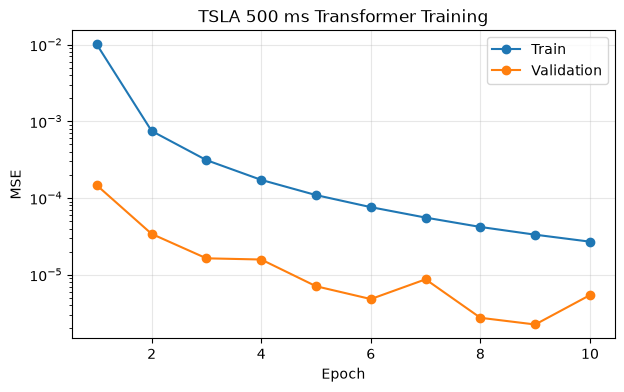

In [18]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(7, 4))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation"
)

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("TSLA 500 ms Transformer Training")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [19]:
def predict_regression(
    model,
    loader,
    device
):
    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)

            pred = (
                model(X_batch)
                .squeeze(-1)
                .cpu()
                .numpy()
            )

            predictions.append(pred)
            targets.append(y_batch.numpy())

    return (
        np.concatenate(targets),
        np.concatenate(predictions)
    )

In [20]:
y_val_true, y_val_pred = predict_regression(
    model,
    val_loader,
    device
)

transformer_val_metrics = {
    "MAE": mean_absolute_error(
        y_val_true,
        y_val_pred
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_val_true,
            y_val_pred
        )
    ),
    "R2": r2_score(
        y_val_true,
        y_val_pred
    ),
    "Directional Accuracy": np.mean(
        np.sign(y_val_true)
        == np.sign(y_val_pred)
    )
}

pd.Series(transformer_val_metrics)

MAE                       0.000897
RMSE                      0.001499
R2                     -302.873535
Directional Accuracy      0.422132
dtype: float64

In [21]:
correlation = np.corrcoef(
    y_val_true,
    y_val_pred
)[0, 1]

print(
    f"Prediction/target correlation: "
    f"{correlation:.6f}"
)

Prediction/target correlation: -0.011293


In [22]:
# ---------------------------------------------------------
# Validation baselines for TSLA 500 ms return prediction
# ---------------------------------------------------------

# Baseline 1: always predict zero return
zero_pred = np.zeros_like(y_val_true)

# Baseline 2: always predict training-target mean
train_target_mean = train_dataset.y.mean()
mean_pred = np.full_like(y_val_true, train_target_mean)

baseline_rows = []

for name, pred in [
    ("Zero Return", zero_pred),
    ("Training Mean", mean_pred),
    ("Transformer", y_val_pred),
]:
    baseline_rows.append({
        "model": name,
        "MAE": mean_absolute_error(y_val_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_val_true, pred)),
        "R2": r2_score(y_val_true, pred),
        "Directional Accuracy": np.mean(
            np.sign(y_val_true) == np.sign(pred)
        ),
        "Correlation": (
            np.corrcoef(y_val_true, pred)[0, 1]
            if np.std(pred) > 0
            else np.nan
        )
    })

baseline_comparison = pd.DataFrame(baseline_rows)

display(baseline_comparison)

/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,model,MAE,RMSE,R2,Directional Accuracy,Correlation
0,Zero Return,0.000055,0.000086,-0.000002,0.156143,NaN
1,Training Mean,0.000055,0.000086,-0.000001,0.427504,NaN
2,Transformer,0.000897,0.001499,-302.873535,0.422132,-0.011293


In [23]:
diagnostic = pd.DataFrame({
    "y_true": y_val_true,
    "y_pred": y_val_pred
})

display(
    diagnostic.describe(
        percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
    )
)

,y_true,y_pred
count,4.672000e+04,46720.000000
mean,-1.282334e-07,-0.000563
std,8.597182e-05,0.001385
min,-2.331523e-03,-0.039415
1%,-2.478092e-04,-0.003769
5%,-1.303684e-04,-0.002088
50%,0.000000e+00,-0.000512
95%,1.307635e-04,0.000965
99%,2.366282e-04,0.002071
max,9.545916e-04,0.019108


### Target normalization

The initial Transformer regression produced predictions with substantially
larger variance than the true high-frequency returns. Although the raw MSE
appeared numerically small, the model performed far worse than the zero-return
and training-mean baselines.

Because the regression targets are extremely small in magnitude, the target is
standardized using the training-set mean and standard deviation. The Transformer
is trained in standardized target space, while predictions are transformed back
to raw return units before evaluation.

Target normalization parameters are estimated using the training period only.

In [24]:
target_mean = y_train_seq.mean()
target_std = y_train_seq.std()

print("Training target mean:", target_mean)
print("Training target std: ", target_std)

Training target mean: -3.7989287994922126e-08
Training target std:  7.007170910984215e-05


In [25]:
y_train_scaled = (
    y_train_seq - target_mean
) / target_std

y_val_scaled = (
    y_val_seq - target_mean
) / target_std

y_test_scaled = (
    y_test_seq - target_mean
) / target_std

print("Scaled train mean:", y_train_scaled.mean())
print("Scaled train std: ", y_train_scaled.std())

Scaled train mean: 4.055609222375001e-18
Scaled train std:  1.0


In [26]:
train_dataset_scaled = SequenceDataset(
    X_train_seq,
    y_train_scaled,
    task="regression"
)

val_dataset_scaled = SequenceDataset(
    X_val_seq,
    y_val_scaled,
    task="regression"
)

test_dataset_scaled = SequenceDataset(
    X_test_seq,
    y_test_scaled,
    task="regression"
)

train_loader_scaled = DataLoader(
    train_dataset_scaled,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_scaled = DataLoader(
    val_dataset_scaled,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_scaled = DataLoader(
    test_dataset_scaled,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [27]:
model_scaled = MarketTransformer(
    n_features=len(feature_cols),
    sequence_length=SEQUENCE_LENGTH,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    output_dim=1,
).to(device)

criterion = nn.MSELoss()

optimizer_scaled = torch.optim.AdamW(
    model_scaled.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

/var/folders/59/ptwn2fw11d1f_r2gyk1zlb880000gn/T/ipykernel_20313/760382635.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [28]:
MAX_EPOCHS = 20
PATIENCE = 4

history_scaled = []

best_val_loss = np.inf
best_state_scaled = None
best_epoch = None

epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss = train_one_epoch(
        model_scaled,
        train_loader_scaled,
        optimizer_scaled,
        criterion,
        device
    )

    val_loss = evaluate_loss(
        model_scaled,
        val_loader_scaled,
        criterion,
        device
    )

    history_scaled.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch

        best_state_scaled = {
            k: v.detach().cpu().clone()
            for k, v in model_scaled.state_dict().items()
        }

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d} | "
        f"Train MSE: {train_loss:.6f} | "
        f"Val MSE: {val_loss:.6f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping. "
            f"Best epoch: {best_epoch}"
        )
        break

Epoch 01 | Train MSE: 1.012520 | Val MSE: 1.507739
Epoch 02 | Train MSE: 1.001266 | Val MSE: 1.510805
Epoch 03 | Train MSE: 0.999064 | Val MSE: 1.504379
Epoch 04 | Train MSE: 0.997426 | Val MSE: 1.502728
Epoch 05 | Train MSE: 0.997205 | Val MSE: 1.503683
Epoch 06 | Train MSE: 0.996137 | Val MSE: 1.503474
Epoch 07 | Train MSE: 0.995569 | Val MSE: 1.503253
Epoch 08 | Train MSE: 0.994247 | Val MSE: 1.505009
Early stopping. Best epoch: 4


In [88]:
model_scaled.load_state_dict(
    best_state_scaled
)

_, y_val_scaled_pred = predict_regression(
    model_scaled,
    val_loader_scaled,
    device
)

# Use original raw validation targets
y_val_true_raw = np.asarray(y_val_seq).copy()

y_val_pred_raw = (
    y_val_scaled_pred * target_std
    + target_mean
)

In [89]:
scaled_transformer_metrics = {
    "MAE": mean_absolute_error(
        y_val_true_raw,
        y_val_pred_raw
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_val_true_raw,
            y_val_pred_raw
        )
    ),
    "R2": r2_score(
        y_val_true_raw,
        y_val_pred_raw
    ),
    "Directional Accuracy": np.mean(
        np.sign(y_val_true_raw)
        == np.sign(y_val_pred_raw)
    ),
    "Correlation": np.corrcoef(
        y_val_true_raw,
        y_val_pred_raw
    )[0, 1]
}

pd.Series(scaled_transformer_metrics)

MAE                     0.000055
RMSE                    0.000086
R2                      0.001696
Directional Accuracy    0.453532
Correlation             0.044799
dtype: float64

In [90]:
pd.DataFrame({
    "y_true": y_val_true_raw,
    "y_pred": y_val_pred_raw
}).describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
)

,y_true,y_pred
count,4.672000e+04,4.672000e+04
mean,-1.282334e-07,-4.267332e-07
std,8.597182e-05,5.337955e-06
min,-2.331522e-03,-2.265503e-05
1%,-2.478092e-04,-1.211042e-05
5%,-1.303684e-04,-8.605621e-06
50%,0.000000e+00,-7.289667e-07
95%,1.307635e-04,8.895517e-06
99%,2.366282e-04,1.358361e-05
max,9.545916e-04,2.771367e-05


### Initial Transformer regression result

For TSLA at the 500 ms horizon, the normalized-target Transformer achieves a
slightly positive validation R² and an RMSE close to the classical regression
benchmark. Directional accuracy is also very similar to Ridge regression.

The prediction distribution is considerably narrower than the realized return
distribution, indicating conservative predictions toward zero. Overall, the
result suggests weak predictive structure, but does not provide evidence of a
large directional advantage from sequence modeling.

In [32]:
def build_sequence_splits_for_target(
    asset,
    target,
    daily_data,
    scaler,
    feature_cols,
    sequence_length,
):
    X_train_parts = []
    y_train_parts = []

    for date in train_dates:
        X_day, y_day = build_daily_sequences(
            daily_data[(asset, date)],
            feature_cols,
            target,
            scaler,
            sequence_length=sequence_length,
            task="regression"
        )

        X_train_parts.append(X_day)
        y_train_parts.append(y_day)

    X_train = np.concatenate(X_train_parts, axis=0)
    y_train = np.concatenate(y_train_parts, axis=0)

    X_val, y_val = build_daily_sequences(
        daily_data[(asset, val_dates[0])],
        feature_cols,
        target,
        scaler,
        sequence_length=sequence_length,
        task="regression"
    )

    return X_train, y_train, X_val, y_val

In [92]:
def train_transformer_regression(
    asset,
    target,
    max_epochs=20,
    patience=4,
    batch_size=512,
):

    scaler = asset_scalers[asset]

    X_train, y_train, X_val, y_val = (
        build_sequence_splits_for_target(
            asset,
            target,
            daily_data,
            scaler,
            feature_cols,
            SEQUENCE_LENGTH,
        )
    )

    # Target normalization fitted on TRAIN only
    target_mean = y_train.mean()
    target_std = y_train.std()

    y_train_scaled = (
        y_train - target_mean
    ) / target_std

    y_val_scaled = (
        y_val - target_mean
    ) / target_std

    train_ds = SequenceDataset(
        X_train,
        y_train_scaled,
        task="regression"
    )

    val_ds = SequenceDataset(
        X_val,
        y_val_scaled,
        task="regression"
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False
    )

    model = MarketTransformer(
        n_features=len(feature_cols),
        sequence_length=SEQUENCE_LENGTH,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        output_dim=1,
    ).to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-4
    )

    best_val_loss = np.inf
    best_state = None
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        val_loss = evaluate_loss(
            model,
            val_loader,
            criterion,
            device
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)

    _, y_val_scaled_pred = predict_regression(
        model,
        val_loader,
        device
    )

    # Preserve the original validation targets exactly.
    # This is important because exact zero returns must remain zero
    # when computing directional accuracy.
    y_true = np.asarray(y_val).copy()

    y_pred = (
        y_val_scaled_pred * target_std
        + target_mean
    )

    metrics = {
        "asset": asset,
        "target": target,
        "model": "Transformer",
        "best_epoch": best_epoch,
        "MAE": mean_absolute_error(
            y_true, y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true, y_pred
            )
        ),
        "R2": r2_score(
            y_true, y_pred
        ),
        "Directional_Accuracy": np.mean(
            np.sign(y_true)
            == np.sign(y_pred)
        ),
        "Correlation": np.corrcoef(
            y_true, y_pred
        )[0, 1],
    }

    return metrics

In [95]:
transformer_regression_results = []

for asset in assets:

    for target in regression_targets[asset]:

        print(
            "\n",
            "=" * 60,
            "\n",
            asset,
            target
        )

        result = train_transformer_regression(
            asset,
            target
        )

        transformer_regression_results.append(
            result
        )

        print(result)

transformer_regression_results_df = pd.DataFrame(
    transformer_regression_results
)

display(transformer_regression_results_df)


 TSLA target_500ms


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/var/folders/59/ptwn2fw11d1f_r2gyk1zlb880000gn/T/ipykernel_20313/760382635.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because enc

{'asset': 'TSLA', 'target': 'target_500ms', 'model': 'Transformer', 'best_epoch': 3, 'MAE': 5.493742796312519e-05, 'RMSE': np.float64(8.589788502511227e-05), 'R2': 0.001697940237378237, 'Directional_Accuracy': np.float64(0.4551583904109589), 'Correlation': np.float64(0.043835357265655926)}

 TSLA target_2s


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/var/folders/59/ptwn2fw11d1f_r2gyk1zlb880000gn/T/ipykernel_20313/760382635.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because enc

{'asset': 'TSLA', 'target': 'target_2s', 'model': 'Transformer', 'best_epoch': 3, 'MAE': 0.00011951418852949954, 'RMSE': np.float64(0.00017437893375776253), 'R2': -0.0012192559313091156, 'Directional_Accuracy': np.float64(0.48650384228439325), 'Correlation': np.float64(0.01643677439409661)}

 TSLA target_10s


...

/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/var/folders/59/ptwn2fw11d1f_r2gyk1zlb880000gn/T/ipykernel_20313/760382635.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because enc

{'asset': 'BRK.B', 'target': 'target_10s', 'model': 'Transformer', 'best_epoch': 1, 'MAE': 0.0001242909957913242, 'RMSE': np.float64(0.00019168465905965764), 'R2': 0.0028636984164602808, 'Directional_Accuracy': np.float64(0.4511038307530888), 'Correlation': np.float64(0.07076573998282665)}

 BRK.B target_30s


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/var/folders/59/ptwn2fw11d1f_r2gyk1zlb880000gn/T/ipykernel_20313/760382635.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because enc

{'asset': 'BRK.B', 'target': 'target_30s', 'model': 'Transformer', 'best_epoch': 1, 'MAE': 0.0002302865554020917, 'RMSE': np.float64(0.00031773212709917606), 'R2': -0.0024731981941952252, 'Directional_Accuracy': np.float64(0.5138552538522535), 'Correlation': np.float64(0.061523395164576444)}


,asset,target,model,best_epoch,MAE,RMSE,R2,Directional_Accuracy,Correlation
0,TSLA,target_500ms,Transformer,3,0.000055,0.000086,0.001698,0.455158,0.043835
1,TSLA,target_2s,Transformer,3,0.000120,0.000174,-0.001219,0.486504,0.016437
2,TSLA,target_10s,Transformer,1,0.000273,0.000381,-0.003808,0.502302,0.013465
3,AMZN,target_500ms,Transformer,3,0.000046,0.000073,0.011236,0.389127,0.106188
4,AMZN,target_2s,Transformer,3,0.000098,0.000143,-0.000141,0.461866,0.043933
5,AMZN,target_10s,Transformer,1,0.000225,0.000316,-0.000732,0.497527,0.046580
6,BRK.B,target_5s,Transformer,3,0.000081,0.000139,0.010849,0.356768,0.117921
7,BRK.B,target_10s,Transformer,1,0.000124,0.000192,0.002864,0.451104,0.070766
8,BRK.B,target_30s,Transformer,1,0.000230,0.000318,-0.002473,0.513855,0.061523


In [37]:
classical_regression_results = pd.read_csv(
    "../outputs/regression_validation_results.csv"
)

print(classical_regression_results.columns.tolist())
display(classical_regression_results.head())

['asset', 'target', 'model', 'MAE', 'RMSE', 'R2', 'Directional_Accuracy', 'alpha']


,asset,target,model,MAE,RMSE,R2,Directional_Accuracy,alpha
0,TSLA,target_500ms,Persistence,0.000055,0.000086,-0.000003,0.156080,NaN
1,TSLA,target_2s,Persistence,0.000120,0.000175,-0.000012,0.050026,NaN
2,TSLA,target_10s,Persistence,0.000273,0.000381,-0.000056,0.018236,NaN
3,AMZN,target_500ms,Persistence,0.000045,0.000073,-0.000012,0.307773,NaN
4,AMZN,target_2s,Persistence,0.000098,0.000143,-0.000050,0.115436,NaN


In [97]:
# Keep only the best validation Ridge configuration
ridge_candidates = classical_regression_results[
    classical_regression_results["model"] == "Ridge"
].copy()

best_ridge_idx = (
    ridge_candidates
    .groupby(["asset", "target"])["RMSE"]
    .idxmin()
)

ridge_validation = (
    ridge_candidates
    .loc[best_ridge_idx]
    .copy()
)

transformer_validation = (
    transformer_regression_results_df
    .copy()
)

comparison_cols = [
    "asset",
    "target",
    "model",
    "MAE",
    "RMSE",
    "R2",
    "Directional_Accuracy",
]

ridge_vs_transformer = pd.concat(
    [
        ridge_validation[comparison_cols],
        transformer_validation[comparison_cols],
    ],
    ignore_index=True
)

ridge_vs_transformer = (
    ridge_vs_transformer
    .sort_values(["asset", "target", "model"])
    .reset_index(drop=True)
)

display(ridge_vs_transformer)

,asset,target,model,MAE,RMSE,R2,Directional_Accuracy
0,AMZN,target_10s,Ridge,0.000225,0.000316,0.002330,0.497282
1,AMZN,target_10s,Transformer,0.000225,0.000316,-0.000732,0.497527
2,AMZN,target_2s,Ridge,0.000098,0.000143,0.002911,0.467135
3,AMZN,target_2s,Transformer,0.000098,0.000143,-0.000141,0.461866
4,AMZN,target_500ms,Ridge,0.000046,0.000073,0.009656,0.385395
5,AMZN,target_500ms,Transformer,0.000046,0.000073,0.011236,0.389127
6,BRK.B,target_10s,Ridge,0.000124,0.000192,0.004467,0.434889
7,BRK.B,target_10s,Transformer,0.000124,0.000192,0.002864,0.451104
8,BRK.B,target_30s,Ridge,0.000231,0.000321,-0.000528,0.497622
9,BRK.B,target_30s,Transformer,0.000230,0.000318,-0.002473,0.513855


## Transformer Classification

The regression experiments indicate that the Transformer provides limited
improvement in return-magnitude prediction, with R² values generally remaining
close to zero and directional accuracy broadly comparable to Ridge regression.

This motivates evaluating the sequence model directly as a three-class
directional classifier. The objective is to predict DOWN, STATIONARY, or UP
using the same class definitions and temporal train/validation/test separation
used in the classical classification experiments.

## Transformer Classification Setup

The sequence model is now evaluated directly on the three-class directional
prediction task.

The class definitions are kept identical to the classical classification
experiments:

- DOWN: future return < -tau
- STATIONARY: -tau <= future return <= tau
- UP: future return > tau

The thresholds are frozen from the earlier classification analysis and are
not re-estimated using validation or test data.

In [40]:
classification_targets = {
    "TSLA": "target_500ms",
    "AMZN": "target_500ms",
    "BRK.B": "target_5s",
}

classification_thresholds = {
    "TSLA": 1.2559579505356809e-05,
    "AMZN": 2.340029718496282e-05,
    "BRK.B": 1.0220925300501525e-05,
}

print(classification_targets)
print(classification_thresholds)

{'TSLA': 'target_500ms', 'AMZN': 'target_500ms', 'BRK.B': 'target_5s'}
{'TSLA': 1.2559579505356809e-05, 'AMZN': 2.340029718496282e-05, 'BRK.B': 1.0220925300501525e-05}


In [41]:
def build_sequence_splits_for_classification(
    asset,
    target,
    threshold,
    daily_data,
    scaler,
    feature_cols,
    sequence_length,
):
    X_train_parts = []
    y_train_parts = []

    for date in train_dates:
        X_day, y_day = build_daily_sequences(
            daily_data[(asset, date)],
            feature_cols,
            target,
            scaler,
            sequence_length=sequence_length,
            task="classification",
            classification_threshold=threshold,
        )

        X_train_parts.append(X_day)
        y_train_parts.append(y_day)

    X_train = np.concatenate(X_train_parts, axis=0)
    y_train = np.concatenate(y_train_parts, axis=0)

    X_val, y_val = build_daily_sequences(
        daily_data[(asset, val_dates[0])],
        feature_cols,
        target,
        scaler,
        sequence_length=sequence_length,
        task="classification",
        classification_threshold=threshold,
    )

    X_test, y_test = build_daily_sequences(
        daily_data[(asset, test_dates[0])],
        feature_cols,
        target,
        scaler,
        sequence_length=sequence_length,
        task="classification",
        classification_threshold=threshold,
    )

    return (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
    )

In [42]:
asset = "TSLA"
target = classification_targets[asset]
threshold = classification_thresholds[asset]

(
    X_train_cls,
    y_train_cls,
    X_val_cls,
    y_val_cls,
    X_test_cls,
    y_test_cls,
) = build_sequence_splits_for_classification(
    asset,
    target,
    threshold,
    daily_data,
    asset_scalers[asset],
    feature_cols,
    SEQUENCE_LENGTH,
)

print("Train X:", X_train_cls.shape)
print("Train y:", y_train_cls.shape)

print("Validation X:", X_val_cls.shape)
print("Validation y:", y_val_cls.shape)

print("Test X:", X_test_cls.shape)
print("Test y:", y_test_cls.shape)

print("\nTrain class counts:")
print(pd.Series(y_train_cls).value_counts().sort_index())

print("\nValidation class counts:")
print(pd.Series(y_val_cls).value_counts().sort_index())

/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted w

Train X: (140160, 20, 19)
Train y: (140160,)
Validation X: (46720, 20, 19)
Validation y: (46720,)
Test X: (46720, 20, 19)
Test y: (46720,)

Train class counts:
0    47821
1    43689
2    48650
Name: count, dtype: int64

Validation class counts:
0    19931
1     7376
2    19413
Name: count, dtype: int64


In [43]:
class MarketTransformerClassifier(nn.Module):
    def __init__(
        self,
        n_features,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        n_classes=3,
    ):
        super().__init__()

        self.input_projection = nn.Linear(n_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.transformer(x)

        # Representation of the most recent time step
        x = x[:, -1, :]
        x = self.norm(x)

        return self.head(x)


classifier = MarketTransformerClassifier(
    n_features=len(feature_cols)
).to(device)

print(classifier)

print(
    "\nTrainable parameters:",
    sum(p.numel() for p in classifier.parameters() if p.requires_grad)
)

MarketTransformerClassifier(
  (input_projection): Linear(in_features=19, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (head): Linear(in_features=64, out_features=3, bias=True)
)

Trainable parameters: 68547


/var/folders/59/ptwn2fw11d1f_r2gyk1zlb880000gn/T/ipykernel_20313/2876281652.py:25: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [44]:
class_counts = np.bincount(y_train_cls, minlength=3)

class_weights = (
    len(y_train_cls)
    / (3 * class_counts)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device,
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [47821 43689 48650]
Class weights: tensor([0.9770, 1.0694, 0.9603], device='mps:0')


In [45]:
class SequenceClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_cls_dataset = SequenceClassificationDataset(
    X_train_cls, y_train_cls
)

val_cls_dataset = SequenceClassificationDataset(
    X_val_cls, y_val_cls
)

test_cls_dataset = SequenceClassificationDataset(
    X_test_cls, y_test_cls
)


train_cls_loader = DataLoader(
    train_cls_dataset,
    batch_size=512,
    shuffle=True,
)

val_cls_loader = DataLoader(
    val_cls_dataset,
    batch_size=512,
    shuffle=False,
)

test_cls_loader = DataLoader(
    test_cls_dataset,
    batch_size=512,
    shuffle=False,
)


print("Train batches:", len(train_cls_loader))
print("Validation batches:", len(val_cls_loader))
print("Test batches:", len(test_cls_loader))

Train batches: 274
Validation batches: 92
Test batches: 92


## Classification Training

The Transformer classifier is trained with weighted cross-entropy loss.
Class weights are estimated from the training period only.

Model selection is based on validation balanced accuracy rather than raw
accuracy, since the class proportions differ across days.

The March 20 test set remains untouched during training and model selection.

In [46]:
def train_one_epoch_classification(
    model,
    loader,
    optimizer,
    criterion,
    device
):
    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item()
            * len(X_batch)
        )

    return total_loss / len(loader.dataset)

In [47]:
def evaluate_classification(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    all_true = []
    all_pred = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            pred = torch.argmax(
                logits,
                dim=1
            )

            total_loss += (
                loss.item()
                * len(X_batch)
            )

            all_true.append(
                y_batch.cpu().numpy()
            )

            all_pred.append(
                pred.cpu().numpy()
            )

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    return {
        "loss": (
            total_loss / len(loader.dataset)
        ),
        "accuracy": (
            np.mean(y_true == y_pred)
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred
            )
        ),
        "macro_f1": (
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
        ),
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [48]:
criterion_cls = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer_cls = torch.optim.AdamW(
    classifier.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [49]:
MAX_EPOCHS = 20
PATIENCE = 4

classification_history = []

best_balanced_accuracy = -np.inf
best_classifier_state = None
best_classifier_epoch = None

epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss = (
        train_one_epoch_classification(
            classifier,
            train_cls_loader,
            optimizer_cls,
            criterion_cls,
            device
        )
    )

    val_metrics = (
        evaluate_classification(
            classifier,
            val_cls_loader,
            criterion_cls,
            device
        )
    )

    classification_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy":
            val_metrics["balanced_accuracy"],
        "val_macro_f1":
            val_metrics["macro_f1"],
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Acc: {val_metrics['accuracy']:.4f} | "
        f"BA: {val_metrics['balanced_accuracy']:.4f} | "
        f"Macro F1: {val_metrics['macro_f1']:.4f}"
    )

    if (
        val_metrics["balanced_accuracy"]
        > best_balanced_accuracy
    ):
        best_balanced_accuracy = (
            val_metrics["balanced_accuracy"]
        )

        best_classifier_epoch = epoch

        best_classifier_state = {
            k: v.detach().cpu().clone()
            for k, v in classifier.state_dict().items()
        }

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping. "
            f"Best epoch: {best_classifier_epoch}"
        )
        break

Epoch 01 | Train Loss: 1.0844 | Val Loss: 1.0350 | Acc: 0.4432 | BA: 0.3950 | Macro F1: 0.3898
Epoch 02 | Train Loss: 1.0759 | Val Loss: 1.0431 | Acc: 0.4392 | BA: 0.3944 | Macro F1: 0.3789
Epoch 03 | Train Loss: 1.0734 | Val Loss: 1.0397 | Acc: 0.4335 | BA: 0.4033 | Macro F1: 0.3934
Epoch 04 | Train Loss: 1.0725 | Val Loss: 1.0411 | Acc: 0.4385 | BA: 0.4024 | Macro F1: 0.4007
Epoch 05 | Train Loss: 1.0713 | Val Loss: 1.0532 | Acc: 0.4276 | BA: 0.4117 | Macro F1: 0.4045
Epoch 06 | Train Loss: 1.0708 | Val Loss: 1.0332 | Acc: 0.4464 | BA: 0.4009 | Macro F1: 0.4035
Epoch 07 | Train Loss: 1.0701 | Val Loss: 1.0376 | Acc: 0.4422 | BA: 0.4017 | Macro F1: 0.4027
Epoch 08 | Train Loss: 1.0694 | Val Loss: 1.0357 | Acc: 0.4440 | BA: 0.3992 | Macro F1: 0.3950
Epoch 09 | Train Loss: 1.0688 | Val Loss: 1.0486 | Acc: 0.4335 | BA: 0.4062 | Macro F1: 0.4021
Early stopping. Best epoch: 5


In [50]:
classifier.load_state_dict(
    best_classifier_state
)

best_val_metrics = evaluate_classification(
    classifier,
    val_cls_loader,
    criterion_cls,
    device
)

print(
    "Best epoch:",
    best_classifier_epoch
)

print(
    "Validation accuracy:",
    best_val_metrics["accuracy"]
)

print(
    "Validation balanced accuracy:",
    best_val_metrics["balanced_accuracy"]
)

print(
    "Validation macro F1:",
    best_val_metrics["macro_f1"]
)

Best epoch: 5
Validation accuracy: 0.42758989726027397
Validation balanced accuracy: 0.41172434558358334
Validation macro F1: 0.40446407107674204


In [51]:
def run_transformer_classification(
    asset,
    target,
    threshold,
    seed=42,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # --------------------------------------------------
    # Build sequences
    # --------------------------------------------------
    (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
    ) = build_sequence_splits_for_classification(
        asset,
        target,
        threshold,
        daily_data,
        asset_scalers[asset],
        feature_cols,
        SEQUENCE_LENGTH,
    )

    # --------------------------------------------------
    # Datasets / loaders
    # --------------------------------------------------
    train_dataset = SequenceClassificationDataset(X_train, y_train)
    val_dataset = SequenceClassificationDataset(X_val, y_val)
    test_dataset = SequenceClassificationDataset(X_test, y_test)

    train_loader = DataLoader(
        train_dataset,
        batch_size=512,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=512,
        shuffle=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=512,
        shuffle=False,
    )

    # --------------------------------------------------
    # Training-only class weights
    # --------------------------------------------------
    class_counts = np.bincount(y_train, minlength=3)

    weights = len(y_train) / (3 * class_counts)

    weights = torch.tensor(
        weights,
        dtype=torch.float32,
        device=device,
    )

    # --------------------------------------------------
    # Fresh model
    # --------------------------------------------------
    model = MarketTransformerClassifier(
        n_features=len(feature_cols)
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-4,
    )

    # --------------------------------------------------
    # Training
    # --------------------------------------------------
    best_ba = -np.inf
    best_state = None
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(1, 21):

        train_loss = train_one_epoch_classification(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
        )

        val_metrics = evaluate_classification(
            model,
            val_loader,
            criterion,
            device,
        )

        print(
            f"{asset} | Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Acc: {val_metrics['accuracy']:.4f} | "
            f"BA: {val_metrics['balanced_accuracy']:.4f} | "
            f"Macro F1: {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["balanced_accuracy"] > best_ba:

            best_ba = val_metrics["balanced_accuracy"]
            best_epoch = epoch

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= 4:
            break

    # Restore validation-selected model
    model.load_state_dict(best_state)

    final_val = evaluate_classification(
        model,
        val_loader,
        criterion,
        device,
    )

    print(
        f"\n{asset} BEST | "
        f"Epoch: {best_epoch} | "
        f"Acc: {final_val['accuracy']:.4f} | "
        f"BA: {final_val['balanced_accuracy']:.4f} | "
        f"Macro F1: {final_val['macro_f1']:.4f}\n"
    )

    return {
        "asset": asset,
        "target": target,
        "best_epoch": best_epoch,
        "val_accuracy": final_val["accuracy"],
        "val_balanced_accuracy": final_val["balanced_accuracy"],
        "val_macro_f1": final_val["macro_f1"],
        "model": model,

        # Save test loader but DO NOT evaluate yet
        "test_loader": test_loader,
        "criterion": criterion,
    }

In [52]:
transformer_classification_results = {}

for asset in ["TSLA", "AMZN", "BRK.B"]:

    print("\n" + "=" * 80)
    print(asset)
    print("=" * 80)

    result = run_transformer_classification(
        asset=asset,
        target=classification_targets[asset],
        threshold=classification_thresholds[asset],
    )

    transformer_classification_results[asset] = result


TSLA


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted w

TSLA | Epoch 01 | Train Loss: 1.0839 | Val Loss: 1.0492 | Acc: 0.4289 | BA: 0.4069 | Macro F1: 0.3941
TSLA | Epoch 02 | Train Loss: 1.0755 | Val Loss: 1.0279 | Acc: 0.4535 | BA: 0.3865 | Macro F1: 0.3861
TSLA | Epoch 03 | Train Loss: 1.0744 | Val Loss: 1.0386 | Acc: 0.4455 | BA: 0.4024 | Macro F1: 0.4053
TSLA | Epoch 04 | Train Loss: 1.0733 | Val Loss: 1.0388 | Acc: 0.4457 | BA: 0.4002 | Macro F1: 0.4026
TSLA | Epoch 05 | Train Loss: 1.0723 | Val Loss: 1.0409 | Acc: 0.4462 | BA: 0.3978 | Macro F1: 0.4005

TSLA BEST | Epoch: 1 | Acc: 0.4289 | BA: 0.4069 | Macro F1: 0.3941


AMZN


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted w

AMZN | Epoch 01 | Train Loss: 1.0713 | Val Loss: 1.0559 | Acc: 0.4279 | BA: 0.4264 | Macro F1: 0.4272
AMZN | Epoch 02 | Train Loss: 1.0596 | Val Loss: 1.0429 | Acc: 0.4179 | BA: 0.4118 | Macro F1: 0.4030
AMZN | Epoch 03 | Train Loss: 1.0565 | Val Loss: 1.0570 | Acc: 0.4243 | BA: 0.4217 | Macro F1: 0.4216
AMZN | Epoch 04 | Train Loss: 1.0553 | Val Loss: 1.0496 | Acc: 0.4291 | BA: 0.4269 | Macro F1: 0.4276
AMZN | Epoch 05 | Train Loss: 1.0533 | Val Loss: 1.0424 | Acc: 0.4249 | BA: 0.4199 | Macro F1: 0.4165
AMZN | Epoch 06 | Train Loss: 1.0523 | Val Loss: 1.0553 | Acc: 0.4215 | BA: 0.4191 | Macro F1: 0.4195
AMZN | Epoch 07 | Train Loss: 1.0513 | Val Loss: 1.0466 | Acc: 0.4184 | BA: 0.4128 | Macro F1: 0.4075
AMZN | Epoch 08 | Train Loss: 1.0495 | Val Loss: 1.0514 | Acc: 0.4290 | BA: 0.4264 | Macro F1: 0.4237

AMZN BEST | Epoch: 4 | Acc: 0.4291 | BA: 0.4269 | Macro F1: 0.4276


BRK.B


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted w

BRK.B | Epoch 01 | Train Loss: 1.0744 | Val Loss: 1.0665 | Acc: 0.4081 | BA: 0.4092 | Macro F1: 0.4085
BRK.B | Epoch 02 | Train Loss: 1.0565 | Val Loss: 1.0693 | Acc: 0.4109 | BA: 0.4071 | Macro F1: 0.4033
BRK.B | Epoch 03 | Train Loss: 1.0454 | Val Loss: 1.0680 | Acc: 0.4078 | BA: 0.4064 | Macro F1: 0.4039
BRK.B | Epoch 04 | Train Loss: 1.0365 | Val Loss: 1.0731 | Acc: 0.4066 | BA: 0.4043 | Macro F1: 0.3994
BRK.B | Epoch 05 | Train Loss: 1.0266 | Val Loss: 1.0857 | Acc: 0.3956 | BA: 0.3979 | Macro F1: 0.3950

BRK.B BEST | Epoch: 1 | Acc: 0.4081 | BA: 0.4092 | Macro F1: 0.4085



In [53]:
transformer_classification_validation_df = pd.DataFrame([
    {
        "asset": r["asset"],
        "target": r["target"],
        "model": "Transformer",
        "best_epoch": r["best_epoch"],
        "accuracy": r["val_accuracy"],
        "balanced_accuracy": r["val_balanced_accuracy"],
        "macro_f1": r["val_macro_f1"],
    }
    for r in transformer_classification_results.values()
])

display(transformer_classification_validation_df)

,asset,target,model,best_epoch,accuracy,balanced_accuracy,macro_f1
0,TSLA,target_500ms,Transformer,1,0.428896,0.406933,0.394081
1,AMZN,target_500ms,Transformer,4,0.429067,0.426899,0.427604
2,BRK.B,target_5s,Transformer,1,0.408062,0.409208,0.408490


In [54]:
logistic_validation = pd.read_csv(
    "../outputs/classification_validation_results.csv"
)

display(logistic_validation)

,asset,model,accuracy,balanced_accuracy,macro_f1
0,TSLA,Balanced Logistic Regression,0.424421,0.409530,0.400614
1,AMZN,Balanced Logistic Regression,0.424913,0.427740,0.419580
2,BRK.B,Balanced Logistic Regression,0.412883,0.410076,0.407589


In [55]:
comparison_cls = (
    logistic_validation[
        [
            "asset",
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1"
        ]
    ]
    .copy()
)

transformer_cls = (
    transformer_classification_validation_df[
        [
            "asset",
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1"
        ]
    ]
    .copy()
)

classification_model_comparison = pd.concat(
    [
        comparison_cls,
        transformer_cls
    ],
    ignore_index=True
)

display(
    classification_model_comparison.sort_values(
        ["asset", "balanced_accuracy"],
        ascending=[True, False]
    )
)

,asset,model,accuracy,balanced_accuracy,macro_f1
1,AMZN,Balanced Logistic Regression,0.424913,0.427740,0.419580
4,AMZN,Transformer,0.429067,0.426899,0.427604
2,BRK.B,Balanced Logistic Regression,0.412883,0.410076,0.407589
5,BRK.B,Transformer,0.408062,0.409208,0.408490
0,TSLA,Balanced Logistic Regression,0.424421,0.409530,0.400614
3,TSLA,Transformer,0.428896,0.406933,0.394081


## Sequence Classification Conclusion

The Transformer classifier was compared with balanced Logistic Regression using validation data only. Balanced Logistic Regression achieved slightly higher balanced accuracy for all three assets. The differences were small, indicating that the Transformer captured comparable predictive information, but the additional sequence modeling complexity did not improve the primary validation metric.

Therefore, balanced Logistic Regression remains the selected classification model for the final out-of-sample evaluation.

## Final Transformer Classification Test Evaluation

The Transformer classification architecture and training procedure were fixed
using the March 16–18 training period and March 19 validation period.

The saved validation-selected Transformer models are now evaluated on the
held-out March 20 test set. Test performance is reported for comparison with
the classical classification models and is not used for further model
selection or tuning.

In [57]:
transformer_classification_test_results = []
transformer_classification_test_details = {}

for asset in ["TSLA", "AMZN", "BRK.B"]:

    result = transformer_classification_results[asset]

    model = result["model"]
    test_loader = result["test_loader"]
    criterion = result["criterion"]

    test_metrics = evaluate_classification(
        model,
        test_loader,
        criterion,
        device,
    )

    transformer_classification_test_results.append({
        "asset": asset,
        "target": classification_targets[asset],
        "model": "Transformer",
        "accuracy": test_metrics["accuracy"],
        "balanced_accuracy": test_metrics["balanced_accuracy"],
        "macro_f1": test_metrics["macro_f1"],
    })

    transformer_classification_test_details[asset] = {
        "y_true": test_metrics["y_true"],
        "y_pred": test_metrics["y_pred"],
    }

transformer_classification_test_df = pd.DataFrame(
    transformer_classification_test_results
)

display(transformer_classification_test_df)

,asset,target,model,accuracy,balanced_accuracy,macro_f1
0,TSLA,target_500ms,Transformer,0.425150,0.379681,0.366404
1,AMZN,target_500ms,Transformer,0.410745,0.409610,0.407758
2,BRK.B,target_5s,Transformer,0.413222,0.402918,0.398767


In [58]:
class_names = ["DOWN", "STATIONARY", "UP"]

for asset in ["TSLA", "AMZN", "BRK.B"]:

    y_true = transformer_classification_test_details[asset]["y_true"]
    y_pred = transformer_classification_test_details[asset]["y_pred"]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2]
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {c}" for c in class_names],
        columns=[f"Pred {c}" for c in class_names],
    )

    print("=" * 70)
    print(asset)
    print("=" * 70)

    display(cm_df)

TSLA


,Pred DOWN,Pred STATIONARY,Pred UP
Actual DOWN,5493,2346,11919
Actual STATIONARY,1817,1477,4392
Actual UP,4249,2134,12893


AMZN


,Pred DOWN,Pred STATIONARY,Pred UP
Actual DOWN,6640,3499,5843
Actual STATIONARY,4485,4958,5606
Actual UP,4642,3455,7592


BRK.B


,Pred DOWN,Pred STATIONARY,Pred UP
Actual DOWN,3912,4820,5466
Actual STATIONARY,3271,9784,6533
Actual UP,2781,4538,5606


In [59]:
transformer_classification_test_df.to_csv(
    "../outputs/transformer_classification_test_results.csv",
    index=False
)

print("Saved Transformer classification test results.")

Saved Transformer classification test results.


### Transformer Classification Test Observations

The Transformer classifier achieves test balanced accuracies of approximately
0.380 for TSLA, 0.410 for AMZN, and 0.403 for BRK.B.

Compared with the class-balanced Logistic Regression model, the Transformer
does not provide a consistent improvement across assets. Its performance is
lower for TSLA, approximately comparable for AMZN, and moderately higher for
BRK.B. The confusion matrices show that the Transformer predicts all three
classes rather than collapsing to the most frequent class.

These results are consistent with the validation-stage model-selection
decision. Although the sequence model captures predictive information from
the recent order-book history, its additional temporal modeling complexity
does not yield a systematic improvement over the simpler Logistic Regression
approach.

## Final Transformer Regression Test Evaluation

The Transformer regression architecture, sequence length, feature set,
optimizer, target normalization procedure, and early-stopping rule were fixed
using the training and validation periods.

Fresh models are trained with the frozen specification using the training period, with March 19 used only for validation-based checkpoint selection, and are then evaluated on the held-out March 20 test day. Target normalization parameters are estimated
from the training period only. Test performance is used only for final
out-of-sample reporting and is not used for additional tuning or model
selection.

In [78]:
def run_final_transformer_regression(
    asset,
    target,
    seed=42,
    max_epochs=20,
    patience=4,
    batch_size=512,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    scaler = asset_scalers[asset]

    # --------------------------------------------------
    # TRAIN + VALIDATION
    # --------------------------------------------------
    X_train, y_train, X_val, y_val = (
        build_sequence_splits_for_target(
            asset,
            target,
            daily_data,
            scaler,
            feature_cols,
            SEQUENCE_LENGTH,
        )
    )

    # --------------------------------------------------
    # TEST
    # --------------------------------------------------
    X_test, y_test = build_daily_sequences(
        daily_data[(asset, test_dates[0])],
        feature_cols,
        target,
        scaler,
        sequence_length=SEQUENCE_LENGTH,
        task="regression",
    )

    # --------------------------------------------------
    # Target normalization: TRAIN ONLY
    # --------------------------------------------------
    target_mean = y_train.mean()
    target_std = y_train.std()

    y_train_scaled = (
        y_train - target_mean
    ) / target_std

    y_val_scaled = (
        y_val - target_mean
    ) / target_std

    y_test_scaled = (
        y_test - target_mean
    ) / target_std

    # --------------------------------------------------
    # Datasets / loaders
    # --------------------------------------------------
    train_ds = SequenceDataset(
        X_train,
        y_train_scaled,
        task="regression",
    )

    val_ds = SequenceDataset(
        X_val,
        y_val_scaled,
        task="regression",
    )

    test_ds = SequenceDataset(
        X_test,
        y_test_scaled,
        task="regression",
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    # --------------------------------------------------
    # Fresh frozen architecture
    # --------------------------------------------------
    model = MarketTransformer(
        n_features=len(feature_cols),
        sequence_length=SEQUENCE_LENGTH,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        output_dim=1,
    ).to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-4,
    )

    # --------------------------------------------------
    # Validation-based checkpoint selection
    # --------------------------------------------------
    best_val_loss = np.inf
    best_state = None
    best_epoch = None

    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
        )

        val_loss = evaluate_loss(
            model,
            val_loader,
            criterion,
            device,
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_epoch = epoch

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    # Restore validation-selected checkpoint
    model.load_state_dict(best_state)

    # --------------------------------------------------
    # Validation predictions
    # --------------------------------------------------
    _, y_val_scaled_pred = predict_regression(
        model,
        val_loader,
        device,
    )

    # IMPORTANT:
    # Use the original unscaled targets as ground truth.
    # Do not reconstruct them from float32 normalized tensors,
    # because exact zero returns can become tiny +/- values.
    y_val_true = np.asarray(y_val).copy()

    y_val_pred = (
        y_val_scaled_pred * target_std
        + target_mean
    )

    # --------------------------------------------------
    # FINAL TEST predictions
    # --------------------------------------------------
    _, y_test_scaled_pred = predict_regression(
        model,
        test_loader,
        device,
    )

    # Preserve the original exact targets for evaluation
    y_test_true = np.asarray(y_test).copy()

    y_test_pred = (
        y_test_scaled_pred * target_std
        + target_mean
    )

    # --------------------------------------------------
    # Metrics
    # --------------------------------------------------
    validation_metrics = {
        "MAE": mean_absolute_error(
            y_val_true,
            y_val_pred,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_val_true,
                y_val_pred,
            )
        ),
        "R2": r2_score(
            y_val_true,
            y_val_pred,
        ),
        "Directional_Accuracy": np.mean(
            np.sign(y_val_true)
            == np.sign(y_val_pred)
        ),
        "Correlation": np.corrcoef(
            y_val_true,
            y_val_pred,
        )[0, 1],
    }

    test_metrics = {
        "MAE": mean_absolute_error(
            y_test_true,
            y_test_pred,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test_true,
                y_test_pred,
            )
        ),
        "R2": r2_score(
            y_test_true,
            y_test_pred,
        ),
        "Directional_Accuracy": np.mean(
            np.sign(y_test_true)
            == np.sign(y_test_pred)
        ),
        "Correlation": np.corrcoef(
            y_test_true,
            y_test_pred,
        )[0, 1],
    }

    return {
    "asset": asset,
    "target": target,
    "best_epoch": best_epoch,
    "validation": validation_metrics,
    "test": test_metrics,

    # Keep predictions only for diagnostic checks
    "y_test_true": y_test_true,
    "y_test_pred": y_test_pred,
}

In [80]:
final_transformer_regression_results = []

for asset in assets:

    for target in regression_targets[asset]:

        print(
            "\n" + "=" * 70
        )
        print(asset, target)
        print("=" * 70)

        result = run_final_transformer_regression(
            asset=asset,
            target=target,
        )

        final_transformer_regression_results.append(
            result
        )

        print(
            "Best epoch:",
            result["best_epoch"]
        )

        print(
            "Validation R2:",
            round(
                result["validation"]["R2"],
                6
            )
        )

        print(
            "Test R2:",
            round(
                result["test"]["R2"],
                6
            )
        )


TSLA target_500ms


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted w

Best epoch: 5
Validation R2: 0.001968
Test R2: 0.001452

TSLA target_2s


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted w

Best epoch: 2
Validation R2: -0.000143
Test R2: -0.003659

TSLA target_10s


...

Best epoch: 3
Validation R2: 0.016922
Test R2: 0.000167

BRK.B target_10s


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted w

Best epoch: 1
Validation R2: 0.00654
Test R2: 0.004782

BRK.B target_30s


/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bull-ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted w

Best epoch: 1
Validation R2: -0.002269
Test R2: -0.005412


In [81]:
transformer_regression_test_df = pd.DataFrame([
    {
        "asset": r["asset"],
        "target": r["target"],
        "model": "Transformer",
        "best_epoch": r["best_epoch"],
        "MAE": r["test"]["MAE"],
        "RMSE": r["test"]["RMSE"],
        "R2": r["test"]["R2"],
        "Directional_Accuracy":
            r["test"]["Directional_Accuracy"],
        "Correlation":
            r["test"]["Correlation"],
    }
    for r in final_transformer_regression_results
])

display(
    transformer_regression_test_df
)

,asset,target,model,best_epoch,MAE,RMSE,R2,Directional_Accuracy,Correlation
0,TSLA,target_500ms,Transformer,5,0.000055,0.000084,0.001452,0.446725,0.040190
1,TSLA,target_2s,Transformer,2,0.000117,0.000167,-0.003659,0.487596,-0.007414
2,TSLA,target_10s,Transformer,2,0.000273,0.000380,-0.019755,0.497099,-0.059992
3,AMZN,target_500ms,Transformer,2,0.000044,0.000071,0.012056,0.389555,0.113292
4,AMZN,target_2s,Transformer,2,0.000095,0.000138,0.002522,0.472590,0.052904
5,AMZN,target_10s,Transformer,1,0.000219,0.000306,-0.006254,0.488512,0.002538
6,BRK.B,target_5s,Transformer,3,0.000087,0.000156,0.000167,0.316735,0.112234
7,BRK.B,target_10s,Transformer,1,0.000130,0.000213,0.004782,0.420141,0.082653
8,BRK.B,target_30s,Transformer,1,0.000255,0.000366,-0.005412,0.496732,0.013679


In [82]:
transformer_regression_test_df.to_csv(
    "../outputs/transformer_regression_test_results.csv",
    index=False
)

print("Saved Transformer regression test results.")

Saved Transformer regression test results.


In [83]:
classical_test = pd.read_csv("../outputs/regression_test_results.csv")

classical_test.head()

,asset,target,model,alpha,MAE,RMSE,R2,Directional_Accuracy
0,TSLA,target_500ms,Ridge,0.01,0.000055,0.000085,0.001522,0.445880
1,TSLA,target_2s,Ridge,100.00,0.000117,0.000167,-0.001751,0.490692
2,TSLA,target_10s,Ridge,100.00,0.000272,0.000378,-0.010273,0.504067
3,AMZN,target_500ms,Ridge,0.01,0.000044,0.000071,0.011281,0.385973
4,AMZN,target_2s,Ridge,100.00,0.000095,0.000139,0.001451,0.474174


In [84]:

print(classical_test["model"].value_counts())

model
Ridge          9
Train Mean     9
Persistence    9
Name: count, dtype: int64


### All-Horizon Regression Test Comparison

For completeness, the final held-out regression results are reported across
all selected asset-horizon combinations using the same metrics for the
Persistence baseline, training-mean baseline, Ridge regression, and
Transformer sequence model.

This table provides the consistent all-horizon comparison required for
assessing whether the learned models meaningfully outperform naive baselines.
The smaller comparison below focuses on the representative asset-horizon
pairs used for more detailed discussion.

In [85]:
comparison_cols = [
    "asset",
    "target",
    "model",
    "MAE",
    "RMSE",
    "R2",
    "Directional_Accuracy",
]

all_regression_test_comparison = pd.concat(
    [
        classical_test[comparison_cols],
        transformer_regression_test_df[comparison_cols],
    ],
    ignore_index=True
)

all_regression_test_comparison = (
    all_regression_test_comparison
    .sort_values(["asset", "target", "model"])
    .reset_index(drop=True)
)

display(all_regression_test_comparison)

all_regression_test_comparison.to_csv(
    "../outputs/all_regression_test_results.csv",
    index=False
)

,asset,target,model,MAE,RMSE,R2,Directional_Accuracy
0,AMZN,target_10s,Persistence,0.000218,0.000306,-2.103226e-05,0.041588
1,AMZN,target_10s,Ridge,0.000219,0.000308,-7.414061e-03,0.489897
2,AMZN,target_10s,Train Mean,0.000218,0.000307,-8.721545e-05,0.475985
3,AMZN,target_10s,Transformer,0.000219,0.000306,-6.253527e-03,0.488512
4,AMZN,target_2s,Persistence,0.000095,0.000139,-2.062356e-06,0.114109
5,AMZN,target_2s,Ridge,0.000095,0.000139,1.451099e-03,0.474174
6,AMZN,target_2s,Train Mean,0.000095,0.000139,-1.200533e-05,0.440795
7,AMZN,target_2s,Transformer,0.000095,0.000138,2.522246e-03,0.472590
8,AMZN,target_500ms,Persistence,0.000043,0.000071,-4.233716e-07,0.319369
9,AMZN,target_500ms,Ridge,0.000044,0.000071,1.128117e-02,0.385973


In [86]:
selected_targets = {
    "TSLA": "target_500ms",
    "AMZN": "target_500ms",
    "BRK.B": "target_5s",
}

classical_selected = pd.concat([
    classical_test[
        (classical_test["asset"] == asset) &
        (classical_test["target"] == target)
    ]
    for asset, target in selected_targets.items()
])

display(classical_selected)

,asset,target,model,alpha,MAE,RMSE,R2,Directional_Accuracy
0,TSLA,target_500ms,Ridge,0.01,0.000055,0.000085,1.521518e-03,0.445880
9,TSLA,target_500ms,Train Mean,NaN,0.000054,0.000085,-3.071929e-05,0.423843
18,TSLA,target_500ms,Persistence,NaN,0.000054,0.000085,-4.205185e-05,0.162562
3,AMZN,target_500ms,Ridge,0.01,0.000044,0.000071,1.128117e-02,0.385973
12,AMZN,target_500ms,Train Mean,NaN,0.000043,0.000071,-2.463588e-06,0.337277
21,AMZN,target_500ms,Persistence,NaN,0.000043,0.000071,-4.233716e-07,0.319369
6,BRK.B,target_5s,Ridge,100.00,0.000082,0.000155,8.631475e-03,0.305521
15,BRK.B,target_5s,Train Mean,NaN,0.000079,0.000156,-8.538988e-07,0.304537
24,BRK.B,target_5s,Persistence,NaN,0.000079,0.000156,-4.089163e-05,0.417911


In [87]:
# Final regression TEST comparison:
# Persistence + Train Mean + Ridge + Transformer

selected_transformer = pd.concat([
    transformer_regression_test_df[
        (transformer_regression_test_df["asset"] == asset) &
        (transformer_regression_test_df["target"] == target)
    ]
    for asset, target in selected_targets.items()
]).copy()

classical_for_comparison = classical_selected[
    [
        "asset",
        "target",
        "model",
        "MAE",
        "RMSE",
        "R2",
        "Directional_Accuracy",
    ]
].copy()

transformer_for_comparison = selected_transformer[
    [
        "asset",
        "target",
        "model",
        "MAE",
        "RMSE",
        "R2",
        "Directional_Accuracy",
    ]
].copy()

regression_test_comparison = pd.concat(
    [
        classical_for_comparison,
        transformer_for_comparison
    ],
    ignore_index=True
)

regression_test_comparison = (
    regression_test_comparison
    .sort_values(["asset", "target", "model"])
    .reset_index(drop=True)
)

display(regression_test_comparison)

,asset,target,model,MAE,RMSE,R2,Directional_Accuracy
0,AMZN,target_500ms,Persistence,0.000043,0.000071,-4.233716e-07,0.319369
1,AMZN,target_500ms,Ridge,0.000044,0.000071,1.128117e-02,0.385973
2,AMZN,target_500ms,Train Mean,0.000043,0.000071,-2.463588e-06,0.337277
3,AMZN,target_500ms,Transformer,0.000044,0.000071,1.205616e-02,0.389555
4,BRK.B,target_5s,Persistence,0.000079,0.000156,-4.089163e-05,0.417911
5,BRK.B,target_5s,Ridge,0.000082,0.000155,8.631475e-03,0.305521
6,BRK.B,target_5s,Train Mean,0.000079,0.000156,-8.538988e-07,0.304537
7,BRK.B,target_5s,Transformer,0.000087,0.000156,1.670489e-04,0.316735
8,TSLA,target_500ms,Persistence,0.000054,0.000085,-4.205185e-05,0.162562
9,TSLA,target_500ms,Ridge,0.000055,0.000085,1.521518e-03,0.445880


## Sequence Regression Conclusion

The final out-of-sample comparison includes Ridge regression, the Transformer
sequence model, the training-mean baseline, and the persistence baseline.

In terms of return-magnitude prediction, the Transformer does not consistently
outperform Ridge regression. For AMZN at 500 ms, the Transformer achieves a
slightly higher R² than Ridge, while the two models have essentially identical
RMSE. For TSLA at 500 ms, their regression performance is also very similar.
For BRK.B at 5 s, Ridge achieves a substantially higher R² than the Transformer.
Overall, R² values remain small, showing that accurate high-frequency
return-magnitude prediction is difficult.

After preserving exact zero returns when computing directional accuracy, the
Transformer and Ridge also show broadly comparable directional performance on
the selected held-out pairs. Transformer directional accuracy is approximately
0.447 for TSLA at 500 ms, 0.390 for AMZN at 500 ms, and 0.317 for BRK.B at
5 s, compared with approximately 0.446, 0.386, and 0.306 for Ridge,
respectively. The differences are small and do not support a strong directional
advantage for the Transformer.

The naive baselines further emphasize the difficulty of the regression task.
Neither the training-mean nor persistence benchmark provides meaningful
explanatory power in terms of R². More sophisticated models provide only
modest improvements, and no single regression model dominates consistently
across assets, horizons, and metrics.

The test-set results are reported only as a final out-of-sample comparison and
were not used for model selection.

# Overall Sequence-Model Conclusion

The sequence-model experiments investigated whether explicitly modeling the
recent temporal history of order-book features provides predictive
information beyond the classical models.

For regression, the Transformer did not consistently improve RMSE, R², or
directional accuracy relative to Ridge regression. Performance varied by asset
and horizon, but the two model families were generally comparable, with only
small differences in directional accuracy. Thus, explicitly modeling recent
temporal sequences did not provide a consistent regression advantage over the
simpler linear benchmark.

For classification, the Transformer achieved validation performance
comparable to balanced logistic regression, but did not improve balanced
accuracy for any of the three selected asset-horizon pairs. Balanced
logistic regression therefore remained the selected classification model.

Overall, the sequence models provide evidence that temporal order-book
structure contains some predictive information, but the additional
complexity of the Transformer does not yield a consistent improvement over
simpler models. The results therefore reinforce the use of Ridge regression
and balanced logistic regression as the primary benchmark models, while the
Transformer serves as a useful nonlinear sequence-model extension.